- beskriva dricksandelar,
- testa om dricksandelan är högre vid middag än lunch (ensidigt test),
- jämföra andel rökare helg vs vardag (proportionstest)
- modellera dricks i dollar som funktion av notans storlek (enkel linjär regression)


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from scipy import stats 
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from sklearn.linear_model import LinearRegression 

import seaborn as sns

In [2]:
tips = sns.load_dataset("tips").copy()
tips["tip_pct"] = tips["tip"] / tips["total_bill"]
tips["weekend"] = tips["day"].isin(["sat","sun"]).map({True:"weekend", False: "weekday"})

print(f"antal rader:{len(tips)}")
display(tips.head())
display(tips[["total_bill", "tip", "size", "tip_pct"]].describe())




antal rader:244


,total_bill,tip,sex,smoker,day,time,size,tip_pct,weekend
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,weekday
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,weekday
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,weekday
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,weekday
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,weekday


,total_bill,tip,size,tip_pct
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,0.160803
std,8.902412,1.383638,0.951100,0.061072
min,3.070000,1.000000,1.000000,0.035638
25%,13.347500,2.000000,2.000000,0.129127
50%,17.795000,2.900000,2.000000,0.154770
75%,24.127500,3.562500,3.000000,0.191475
max,50.810000,10.000000,6.000000,0.710345


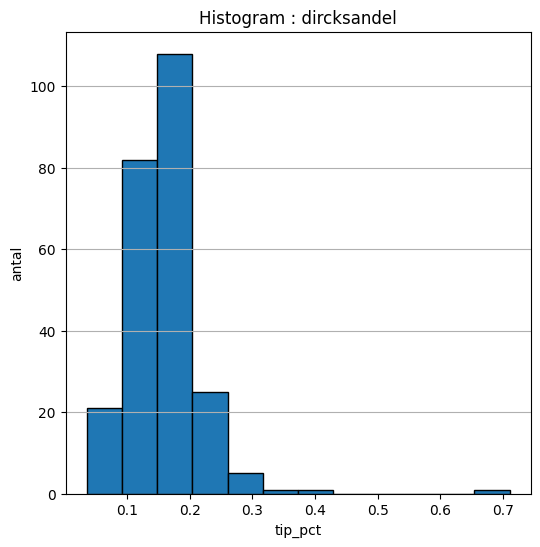

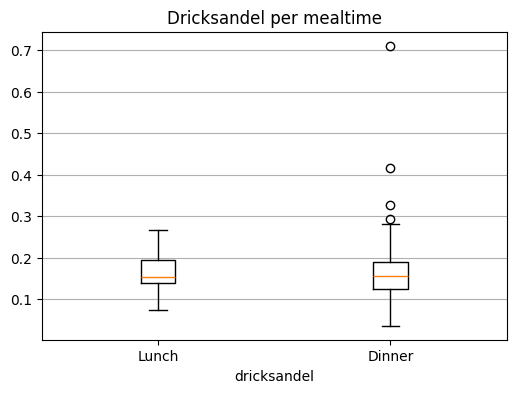

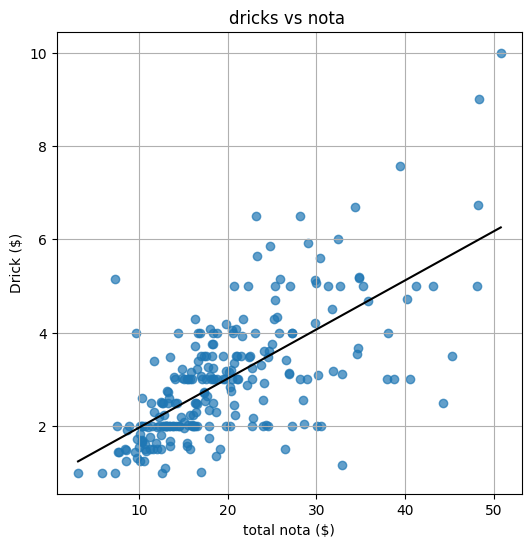

In [3]:
# Histogram tips_pct


plt.figure(figsize = (6,6))
plt.hist(tips["tip_pct"], bins=12, edgecolor="black")
plt.title("Histogram : dircksandel")
plt.xlabel("tip_pct")
plt.ylabel("antal")
plt.grid(axis="y")

plt.show()

#Boxplot tip_pct per mealtime

data_L = tips.loc[tips["time"] == "Lunch", "tip_pct"].values
data_D = tips.loc[tips["time"] == "Dinner", "tip_pct"].values

plt.figure(figsize = (6,4))
plt.boxplot([data_L, data_D], tick_labels=["Lunch", "Dinner"])
plt.title("Dricksandel per mealtime")
plt.xlabel("dricksandel")

plt.grid(axis="y")

plt.show()

#scatter tips($) vs total_bill + enkel line
x= tips["total_bill"].values
y= tips["tip"].values
coef = np.polyfit(x,y, deg=1)
x_line = np.linspace (x.min(), x.max(), 200)
y_line = coef[0] * x_line + coef [1]

plt.figure(figsize = (6,6))
plt.scatter(x,y, alpha=0.7)
plt.plot(x_line, y_line, color="black")
plt.title("dricks vs nota ")
plt.xlabel("total nota ($)")
plt.ylabel("Drick ($)")
plt.grid(True)

plt.show()


## Medel dricksandel + osakerhet (95% CI) 

In [4]:
rng = np.random.default_rng(42)

tip_pct = tips["tip_pct"].values
n = tip_pct.size
mean_tip = tip_pct.mean()
sd_tip = tip_pct.std(ddof=1)
se_tip = sd_tip / np.sqrt(n)

z = 1.96 
ci_low_norm = mean_tip - z * se_tip
ci_high_norm = mean_tip + z * se_tip

n_boot = 10_000
boot_means = []
for _ in range (n_boot):
    sample = rng.choice(tip_pct, size=n , replace=True)
    boot_means.append(sample.mean())

ci_low_boot, ci_high_boot = np.percentile(boot_means, [2.5, 97.5] )

print (f"""
------ medal dricksandel---------
n = {n}
medal (tip_pct)   : {mean_tip*100:5.1f}%
SD                : {sd_tip:0.6f}
SE                : {se_tip:0.12f}
95% CI (normal)   : {ci_low_norm*100:4.1f}% till {ci_high_norm*100:4.1f}%
95% CI (bootstrap): {ci_low_boot*100:4.1f}% till {ci_high_boot*100:4.1f}%     
      """)


------ medal dricksandel---------
n = 244
medal (tip_pct)   :  16.1%
SD                : 0.061072
SE                : 0.003909747238
95% CI (normal)   : 15.3% till 16.8%
95% CI (bootstrap): 15.4% till 16.8%     
      


## Ensidigt test : ar dricksandelen hogre vid middag an lunch

**Hypoteser**   
H_0 : dinner = lunch   
H_1 : dinner > lunch

In [5]:
tip_pct_D = tips.loc[tips["time"]== "Dinner", "tip_pct"].values
tip_pct_L = tips.loc[tips["time"]== "Lunch", "tip_pct"].values

n_D, n_L = len(tip_pct_D), len(tip_pct_L)
mean_D, mean_L = tip_pct_D.mean(), tip_pct_L.mean()
diff_pp = (mean_D - mean_L) * 100

#ensidigt t test : dinner > lunch , welch-variant
t_stat , p_one = stats.ttest_ind(
    tip_pct_D, tip_pct_L,
    equal_var= False,
    alternative= "greater"

)

print (f"""
------ ensidigt test : dinner > lunch (dricksandel)---------
n_Dinner, n_Lunch       : {n_D} {n_L}
medal dinner            :  {mean_D: .3%}
medal Lunch             : {mean_L : .3%}
skillnad (D - L)        : {diff_pp: .1f}
t-stat                  : {t_stat: .3f}
p (ensidige , D> L)     : {p_one :.6f}
      """)


------ ensidigt test : dinner > lunch (dricksandel)---------
n_Dinner, n_Lunch       : 176 68
medal dinner            :   15.952%
medal Lunch             :  16.413%
skillnad (D - L)        : -0.5
t-stat                  : -0.654
p (ensidige , D> L)     : 0.743082
      


**tolkning:**  p values is greater so we can not show that dinner is greater than lunch. this observated difference is small and controdict the statement.

In [ ]:
#- jämföra andel rökare helg vs vardag (proportionstest)
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

is_weekend = tips["day"].isin(["sat", "sun"])
smoker_yes = tips["smoker"] == "yes"

x_weekend = (smoker_yes & is_weekend).sum()
n_weekend = is_weekend.sum()

x_weekday = (smoker_yes & ~is_weekend).sum()
n_weekday = (~is_weekend).sum()

p_weekend = x_weekend / n_weekend
p_weekday = x_weekday / n_weekday
diff_pp = (p_weekend - p_weekday) *100

z_stat, p_two = proportions_ztest(
    count=[x_weekend, x_weekday],
    nobs= [n_weekend, n_weekday],
    alternative= " two sided"
)

ci_low, ci_high = confint_proportions_2indep(
    count1= x_weekend, nobs1= n_weekend,
    count2= x_weekday, nobs2=n_weekday,
    method= "score"
)

print(f"""
------ prportionstest: rokare helg vs vardag -------
      
Helg                          :{x_weekend} / {n_weekend} => {p_weekend : .1%}
Vardag                        :{x_weekday} / {n_weekday} => {p_weekday : .1%}
Skillnad (helg - vardag)      :{diff_pp: .1f}%
z-stat                        :{z_stat: .3f}
p (twosided)                  :{p_two: .6f}
95& CI for p_helg - p_vardag  :[{ci_low: .3f}, {ci_high: .3f}]


""")


C:\Users\Banin\AppData\Local\Temp\ipykernel_15436\1718009949.py:13: RuntimeWarning: invalid value encountered in scalar divide
  p_weekend = x_weekend / n_weekend
c:\Users\Banin\Desktop\Del-2\.venv\Lib\site-packages\statsmodels\stats\proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
c:\Users\Banin\Desktop\Del-2\.venv\Lib\site-packages\statsmodels\stats\proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)
c:\Users\Banin\Desktop\Del-2\.venv\Lib\site-packages\statsmodels\stats\proportion.py:1023: RuntimeWarning: invalid value encountered in scalar multiply
  var_ = p_pooled * (1 - p_pooled) * nobs_fact


ValueError: invalid alternative